# Phase I · Week 1 · NumPy fluencyNotebook de la primera semana del roadmap NEUROFORGE. Objetivo de la semana: dominar NumPy lo suficiente para implementar las cinco operaciones fundamentales de procesado de imagen sin escribir un solo bucle Python.Las operaciones cubiertas aquí son:1. **Histograma de intensidades** — qué frecuencia tiene cada valor de píxel en una imagen.2. **Umbralización binaria (threshold)** — convertir una imagen en escala de grises a una imagen binaria (blanco / negro).3. **PSNR (Peak Signal-to-Noise Ratio)** — métrica para medir la diferencia entre dos imágenes.4. **Filtro media 3x3** — suavizar una imagen sustituyendo cada píxel por la media de sus vecinos.5. **Dilation morfológica binaria 3x3** — operación clásica de morfología matemática.Todas las operaciones se implementan vectorizadas. La regla autoimpuesta es: ningún `for` ni `while` que recorra píxeles.Las técnicas que se aprenden aquí son la base de todo el procesado de imagen clásico y de los layers convolucionales que vendrán en fases posteriores.

## 1. Imports`numpy` es la librería numérica fundamental: todo lo que sigue se apoya en sus arrays N-dimensionales. `matplotlib.pyplot` se usa para visualizar tanto los histogramas como las imágenes resultantes.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Crear imágenes de pruebaPara verificar que las funciones se comportan como se espera se generan dos imágenes sintéticas:- `img`: imagen aleatoria uniforme de 256x256 píxeles, valores enteros en el rango [0, 255]. Se especifica `dtype=np.uint8` porque los píxeles de una imagen real en escala de grises caben en un byte. Trabajar en `uint8` ahorra memoria y representa de forma fiel los datos.- `img2`: imagen constante con todos los píxeles a valor 128. Sirve como caso degenerado: cualquier histograma debe tener un único pico, cualquier filtro media debe devolver la misma constante, etc.Tener pares de "caso normal" y "caso degenerado" es la forma más barata de detectar errores en una función.

In [30]:
img = np.random.randint(0, 256, size=(256,256), dtype=np.uint8)
img2 = np.full((256, 256), 128, dtype=np.uint8)

## 3. Histograma con `np.bincount`El histograma de una imagen es un array de 256 posiciones donde la posición *i* indica cuántos píxeles tienen el valor *i*. `np.bincount` es la función exacta para esto: dado un array de enteros no negativos, devuelve las cuentas de cada valor.`img.ravel()` aplana la imagen 2D a un vector 1D de 65536 elementos. `minlength=256` fuerza que el array de salida tenga siempre 256 posiciones, incluso si la imagen no contiene todos los valores posibles (por ejemplo en `img2` solo aparece el valor 128).Verificación clave: `hist.sum()` debe ser igual al número total de píxeles (256 * 256 = 65536). Si no coincide, se han perdido o duplicado valores en el camino.

In [32]:
hist = np.bincount(img.ravel(), minlength=256)
hist2 = np.bincount(img2.ravel(), minlength=256)

## 4. Visualización con clase `HistogramPlotter`En lugar de escribir dos veces el mismo código de plot para `hist` y `hist2`, se encapsula la lógica de visualización en una clase reutilizable.El método especial `__call__` permite que la instancia se invoque como si fuera una función: `plots(hist, "titulo")`. Es el mismo patrón que usan los modelos de PyTorch (`output = model(input)`) y los datasets (`x = dataset[i]`). Familiarizarse con `__call__` ahora ahorra confusión cuando se llegue a deep learning.`__init__` se ejecuta una sola vez al construir el objeto y guarda el eje X (los valores 0..255) en `self.x_axis`. `__call__` se ejecuta una vez por cada llamada y solo cambia el histograma a representar y el título.Para una imagen aleatoria uniforme se espera un histograma plano alrededor de 256 (= 65536 / 256). Para la imagen constante a 128 se espera un único pico de altura 65536 en x = 128 y todo el resto a cero.

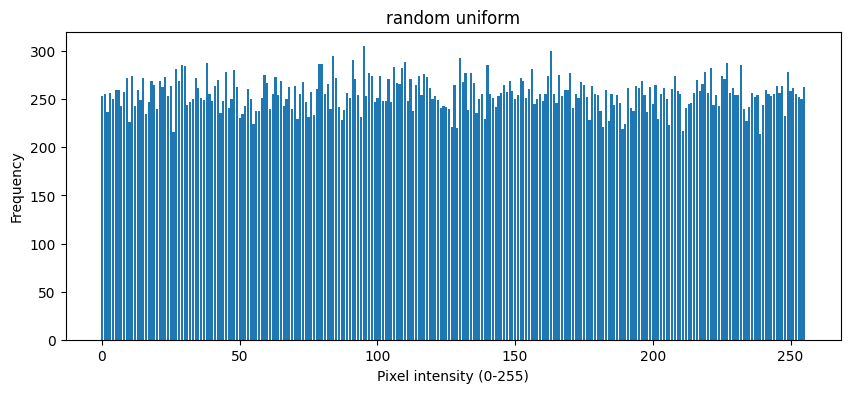

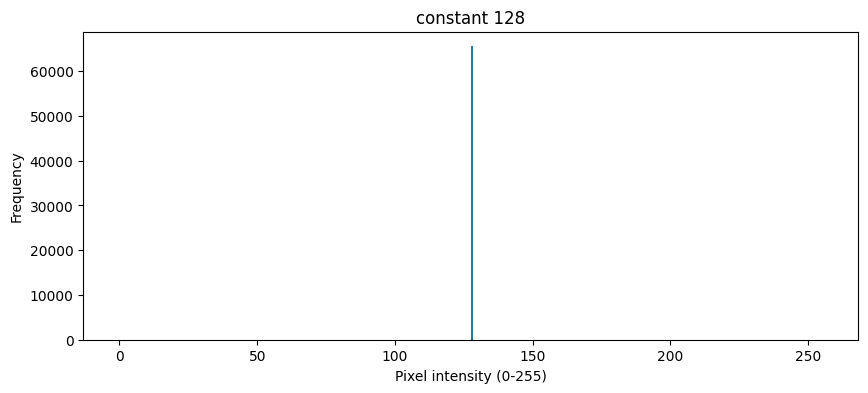

(256,)
int64


In [33]:

class HistogramPlotter:
    def __init__(self, x_axis):
        self.x_axis = x_axis
    def __call__(self, hist, titulo):
        plt.figure(figsize=(10,4))
        plt.bar(self.x_axis, hist)
        plt.xlabel("Pixel intensity (0-255)")
        plt.ylabel("Frequency")
        plt.title(titulo)
        plt.show()

plots = HistogramPlotter(np.arange(256))
plots(hist, "random uniform")
plots(hist2, "constant 128")
print(plots.x_axis.shape)
print(plots.x_axis.dtype)

## 5. Umbralización binariaFunción que convierte una imagen en escala de grises a una imagen binaria: cada píxel pasa a 255 si su valor es mayor o igual al umbral, y a 0 en caso contrario.El truco vectorizado consiste en aprovechar que las comparaciones en NumPy (`>=`, `<`, `==`) devuelven arrays booleanos del mismo shape que la entrada. Multiplicar un array booleano por 255 promociona los valores a entero (`True` se convierte en 1, `False` en 0; al multiplicar por 255 quedan 255 y 0). Después se castea a `uint8` para mantener la representación correcta de imagen.Esta operación es la base de todas las segmentaciones binarias que se verán más adelante: detección de bordes binaria, máscaras de regiones de interés, segmentaciones simples por intensidad.

255 255
0 0


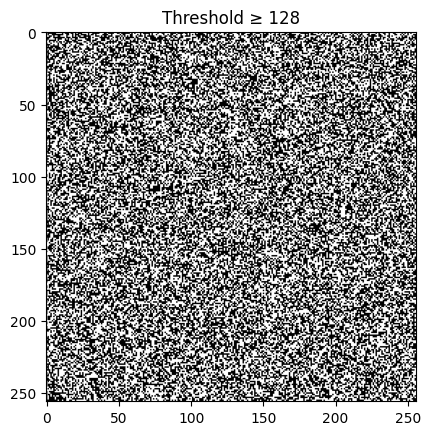

In [35]:
def threshold(img, umbral):
    binary = ((img >= umbral) *255).astype(np.uint8)
    return binary
# Test 1: imagen toda 200, umbral 128 → todo 255
test1 = threshold(np.full((256,256), 200, dtype=np.uint8), 128)
print(test1.min(), test1.max())  # debe ser 255 255

# Test 2: imagen toda 50, umbral 128 → todo 0
test2 = threshold(np.full((256,256), 50, dtype=np.uint8), 128)
print(test2.min(), test2.max())  # debe ser 0 0

# Test 3: imagen aleatoria, umbral 128 → visualiza
binary = threshold(img, 128)
plt.imshow(binary, cmap='gray')
plt.title("Threshold ≥ 128")
plt.show()

## 6. PSNR (Peak Signal-to-Noise Ratio)PSNR mide la calidad de una reconstrucción comparando una imagen contra su versión "verdadera". Es la métrica estándar en compresión de imagen (JPEG, MPEG, H.264), denoising, super-resolución y segmentación de bajo nivel.Fórmula:`PSNR = 10 * log10( MAX² / MSE )`donde `MAX = 255` para imágenes uint8 y `MSE` es el error cuadrático medio entre las dos imágenes.Detalle crítico de implementación: si las dos imágenes son `uint8` y se restan directamente, los valores negativos provocan underflow (envuelven a 255 - x). Hay que convertir al menos una de las dos imágenes a un tipo con signo (`float64` aquí) antes de restar. Este es un error silencioso muy común al empezar con NumPy.Caso degenerado: si las dos imágenes son idénticas, MSE = 0 y la división por cero da infinito. Se maneja explícitamente con un guard al principio de la función para evitar el `RuntimeWarning` de NumPy.Interpretación práctica de los valores:- PSNR > 40 dB: indistinguibles para el ojo humano.- 30-40 dB: buena calidad, equivalente a JPEG con compresión moderada.- 20-30 dB: degradación visible.- < 10 dB: la imagen es esencialmente ruido o totalmente diferente.

In [38]:
def psnr(a, b):
    diff = a.astype(np.float64) - b.astype(np.float64)
    mse = np.mean(diff ** 2)
    if mse == 0:
        return np.inf
    return 10 * np.log10(255**2 / mse)
print("idénticas:    ", psnr(img, img))
print("negativo:     ", psnr(img, 255 - img))
print("diff de 1px:  ", psnr(img, (img.astype(np.int32) + 1).clip(0, 255).astype(np.uint8)))

idénticas:     inf
negativo:      4.749728255651969
diff de 1px:   48.14826717810426


## 7. `sliding_window_view` — la herramienta para vecindadesPara implementar filtros que operan sobre vecindades de píxeles (filtro media 3x3, dilation, erosión, max-pooling, etc.) sin bucles, NumPy ofrece `sliding_window_view` en `numpy.lib.stride_tricks`.Dada una imagen `(H, W)` y un tamaño de ventana `(k, k)`, devuelve una vista de shape `(H-k+1, W-k+1, k, k)`. Cada elemento de las dos primeras dimensiones contiene un sub-array `(k, k)` con los valores de la vecindad centrada en esa posición.Importante: es una **vista**, no una copia. No reserva memoria adicional. Internamente solo manipula los strides del array original.Para una imagen de 256x256 con ventana 3x3, el resultado es `(254, 254, 3, 3)`. Las dos primeras dimensiones son las posiciones espaciales válidas (se pierde un píxel a cada lado del borde porque la ventana 3x3 no cabe). Las dos últimas son los 9 valores de cada ventana.Una vez se tiene este array de 4 dimensiones, aplicar cualquier filtro lineal o no lineal sobre vecindades 3x3 se reduce a un `.mean(axis=(-2, -1))`, `.max(axis=(-2, -1))`, `.min(axis=(-2, -1))`, etc.

In [39]:
from numpy.lib.stride_tricks import sliding_window_view
windows = sliding_window_view(img, (3, 3))
print(windows.shape)

(254, 254, 3, 3)


## 8. Filtro media 3x3Sustituir cada píxel por la media aritmética de su vecindad 3x3. Es el filtro paso-bajo más sencillo posible: atenúa altas frecuencias (ruido píxel a píxel) y conserva bajas frecuencias (regiones homogéneas).Sobre el array `(254, 254, 3, 3)` que devuelve `sliding_window_view`, basta con promediar las dos últimas dimensiones (`axis=(-2, -1)`). El resultado es un array `(254, 254)` donde cada valor es la media de los 9 píxeles de la ventana correspondiente.El dtype del resultado es `float64` aunque la entrada sea `uint8`: la media de enteros no es necesariamente entera, NumPy promociona automáticamente para no perder precisión.Visualizar la imagen filtrada requiere especificar `vmin=0, vmax=255` en `imshow` o castearla a `uint8` antes, porque `imshow` con floats asume rango [0, 1] por defecto.Sobre una imagen de ruido aleatorio uniforme la diferencia es notable: la imagen filtrada tiende visualmente a un gris medio (valor 127) porque la media de un ruido uniforme tiende a la media del rango. Sobre imágenes naturales el efecto es un suavizado / desenfoque suave, similar a un filtro Gaussian con sigma pequeña.

In [40]:
filtered = windows.mean(axis=(-2, -1))
print(filtered.shape)
print(filtered.dtype)

(254, 254)
float64


## 9. Verificación del filtro mediaDos pruebas para confirmar que el filtro está bien implementado:- **Test 1 (imagen constante)**: aplicar el filtro a una imagen donde todos los píxeles valen 100 debe devolver una imagen donde todos los píxeles siguen valiendo 100. La media de nueve cienes es cien. Si `min` y `max` no coinciden a 100.0, hay un bug.- **Test 2 (visualización comparativa)**: mostrar original vs filtrada lado a lado. Sobre la imagen aleatoria uniforme, la versión filtrada debe verse más uniforme y gris medio. Si se ve igual a la original, el filtro no se está aplicando.

100.0 100.0


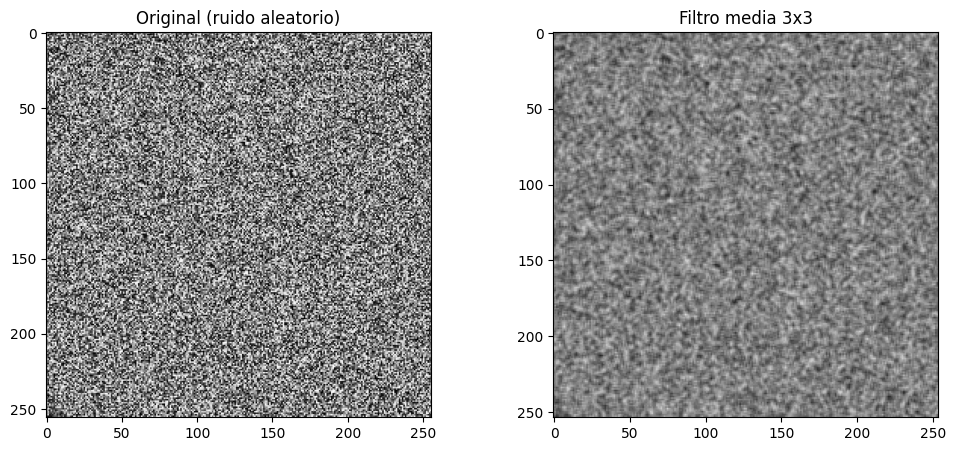

In [41]:
# Test 1: imagen constante → la media es la misma constante
const = np.full((256, 256), 100, dtype=np.uint8)
const_windows = sliding_window_view(const, (3, 3))
const_filtered = const_windows.mean(axis=(-2, -1))
print(const_filtered.min(), const_filtered.max())  # debe ser 100.0 100.0

# Test 2: visualiza original vs filtrada
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original (ruido aleatorio)")
axes[1].imshow(filtered, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Filtro media 3x3")
plt.show()

## 10. Dilation morfológica 3x3 (binaria)La dilation es una de las operaciones fundamentales de morfología matemática. Sobre una imagen binaria, asigna 255 a un píxel si **al menos uno** de su vecindad 3x3 vale 255, y 0 en caso contrario. Visualmente, las regiones blancas crecen un píxel en cada dirección.La implementación es estructuralmente idéntica al filtro media: se construyen las ventanas con `sliding_window_view` y se reduce sobre los dos últimos ejes. La única diferencia es que se usa `.max()` en lugar de `.mean()`. Si la ventana contiene cualquier 255, el máximo es 255; si todos son 0, el máximo es 0. Esa es exactamente la definición de dilation.Aplicaciones prácticas:- Cerrar pequeños agujeros en una segmentación.- Conectar componentes que están muy cerca pero no se tocan.- Engordar máscaras de regiones de interés antes de aplicarlas.- Generar contornos restando la imagen original a su dilation.En CV médica esta operación se usa constantemente para limpiar máscaras de tejido antes de pasarlas a un análisis cuantitativo. En fases posteriores se reemplazará por las versiones de scikit-image y de MONAI, pero la idea es exactamente la misma.El test verifica el caso canónico: un único píxel a 255 en una imagen vacía. Después de la dilation, ese píxel se ha "expandido" a un cuadrado 3x3 de 255. La imagen resultante tiene shape `(8, 8)` (10 - 3 + 1 = 8) por la pérdida de un píxel en cada borde, igual que en el filtro media.

In [42]:
def dilation_3x3(binary_img):
    windows = sliding_window_view(binary_img, (3, 3))
    return windows.max(axis=(-2, -1)).astype(np.uint8)

test = np.zeros((10, 10), dtype=np.uint8)
test[5,5] = 255
print(dilation_3x3(test))

[[  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0 255 255 255   0   0]
 [  0   0   0 255 255 255   0   0]
 [  0   0   0 255 255 255   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]


## Cierre del Wk 1Las cinco operaciones implementadas en este notebook cubren los cimientos del procesado clásico de imagen:| Operación | Reducción usada | Donde se usa después ||-----------|-----------------|----------------------|| Histograma | `np.bincount` | Ecualización, threshold de Otsu (Phase II) || Threshold | `>=` + cast a uint8 | Segmentación binaria, máscaras || PSNR | `np.mean` + `np.log10` | Métricas de denoising y super-resolución || Filtro media | `.mean(axis=(-2,-1))` | Convoluciones, average pooling, Gaussian smoothing || Dilation | `.max(axis=(-2,-1))` | Morfología, max pooling, post-procesado de máscaras |El patrón clave que se repite en las dos últimas: `sliding_window_view + reducción sobre los últimos ejes`. Cualquier operación de vecindad cabe en este molde con la reducción adecuada.Próximo paso: ejercicios de **broadcasting** en `wk01_broadcasting.ipynb`, que es la otra mitad de la fluencia con NumPy.